# Final Dataset Construction

This notebook combines all engineered features produced during the data preparation phase.

Sources:
- listings_features.csv
- review_features.csv

The resulting dataset will be used for machine learning models such as Decision Trees and Random Forests.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)

Project root: /Users/santiagotawata/Desktop/airbnb-rome-analysis


## 1. Load Engineered Datasets

The datasets generated in Notebook 02 and Notebook 03 are loaded and prepared for integration.

- listings_features.csv
- review_features.csv

In [2]:
listings_features = pd.read_csv(
    "../data/listings_features.csv"
)

review_features = pd.read_csv(
    "../data/review_features.csv"
)
seasonality_features = pd.read_csv(
    "../data/seasonality_features.csv"
    )

## 2. Dataset Inspection

Before merging the datasets, we verify their dimensions, structure, and merge keys.

In [3]:
print(listings_features.shape)
print(review_features.shape)

(33564, 67)
(32826, 9)


In [4]:
listings_features.head()

,id,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,...,neighbourhood_cleansed_VII San Giovanni/Cinecittà,neighbourhood_cleansed_VIII Appia Antica,neighbourhood_cleansed_X Ostia/Acilia,neighbourhood_cleansed_XI Arvalia/Portuense,neighbourhood_cleansed_XII Monte Verde,neighbourhood_cleansed_XIII Aurelia,neighbourhood_cleansed_XIV Monte Mario,neighbourhood_cleansed_XV Cassia/Flaminia,distance_to_colosseum,location_cluster
0,2737,57.0,41.871360,12.482150,1,1.0,1.0,1.5,0,0.0,...,0,1,0,0,0,0,0,0,2.252726,3.0
1,11834,110.0,41.895447,12.491181,2,1.0,1.0,1.0,1,100.0,...,0,0,0,0,0,0,0,0,0.588865,4.0
2,12398,124.0,41.925820,12.469280,6,2.0,3.0,1.0,1,100.0,...,0,0,0,0,0,0,0,0,4.389669,1.0
3,19965,162.0,41.908230,12.452930,5,2.0,3.0,1.0,0,100.0,...,0,0,0,0,0,0,0,0,3.824847,1.0
4,19967,150.0,41.908283,12.452617,5,2.0,3.0,1.0,0,100.0,...,0,0,0,0,0,0,0,0,3.850102,1.0


In [5]:
review_features.head()

,listing_id,review_count,avg_review_length,avg_sentiment_score,sentiment_label,latest_review_year,latest_review_month,latest_review_day,days_since_latest_review
0,2737,5,51.800000,0.956560,positive,2015,5,8,4077
1,11834,302,74.165563,0.849785,positive,2026,6,7,29
2,12398,85,84.658824,0.719140,positive,2025,8,1,339
3,19965,195,44.953846,0.463973,positive,2026,6,13,23
4,20534,50,60.200000,0.730592,positive,2022,11,22,1322


In [6]:
seasonality_features.head()

,Month_num,Seasonality_Index,season,month_sin,month_cos
0,1,0.000000,Winter,0.500000,8.660254e-01
1,2,0.104247,Winter,0.866025,5.000000e-01
2,3,0.395881,Spring,1.000000,6.123234e-17
3,4,0.692730,Spring,0.866025,-5.000000e-01
4,5,0.906591,Spring,0.500000,-8.660254e-01


In [7]:
print(review_features.columns.tolist())

['listing_id', 'review_count', 'avg_review_length', 'avg_sentiment_score', 'sentiment_label', 'latest_review_year', 'latest_review_month', 'latest_review_day', 'days_since_latest_review']


### 2.1 Verify Merge Keys

The listings dataset uses the variable id as its primary identifier, while the review dataset uses listing_id.

We verify that both identifiers exist before performing the merge operation.

In [8]:
print("id" in listings_features.columns)
print("listing_id" in review_features.columns)

True
True


## 3. Merge Listings and Review Features

Review-derived variables are merged with the listings dataset using the Airbnb listing identifier.

A left join is used so that all listings remain in the final dataset, even if some properties have never received reviews.

In [9]:
final_df = listings_features.merge(
    review_features,
    left_on="id",
    right_on="listing_id",
    how="left"
)

#deletion of duplicate key
final_df.drop(
    columns=["listing_id"],
    inplace=True
)

In [10]:
month_key = final_df["latest_review_month"].replace(-1, np.nan)

final_df = final_df.merge(
    seasonality_features,
    left_on=month_key,
    right_on="Month_num",
    how="left",
).drop(columns=["Month_num"])

In [11]:
final_df.head()

,id,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,...,avg_sentiment_score,sentiment_label,latest_review_year,latest_review_month,latest_review_day,days_since_latest_review,Seasonality_Index,season,month_sin,month_cos
0,2737,57.0,41.871360,12.482150,1,1.0,1.0,1.5,0,0.0,...,0.956560,positive,2015.0,5.0,8.0,4077.0,0.906591,Spring,5.000000e-01,-0.866025
1,11834,110.0,41.895447,12.491181,2,1.0,1.0,1.0,1,100.0,...,0.849785,positive,2026.0,6.0,7.0,29.0,0.899881,Summer,1.224647e-16,-1.000000
2,12398,124.0,41.925820,12.469280,6,2.0,3.0,1.0,1,100.0,...,0.719140,positive,2025.0,8.0,1.0,339.0,0.650089,Summer,-8.660254e-01,-0.500000
3,19965,162.0,41.908230,12.452930,5,2.0,3.0,1.0,0,100.0,...,0.463973,positive,2026.0,6.0,13.0,23.0,0.899881,Summer,1.224647e-16,-1.000000
4,19967,150.0,41.908283,12.452617,5,2.0,3.0,1.0,0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print(final_df.shape)

(33564, 79)


In [13]:
final_df.columns.to_list()

['id',
 'price',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'beds',
 'bathrooms',
 'host_is_superhost',
 'host_response_rate',
 'host_acceptance_rate',
 'review_scores_rating',
 'review_scores_cleanliness',
 'review_scores_location',
 'review_scores_value',
 'number_of_reviews',
 'reviews_per_month',
 'minimum_nights',
 'maximum_nights',
 'beds_per_guest',
 'bathrooms_per_guest',
 'amenities_count',
 'has_wifi',
 'has_air_conditioning',
 'has_kitchen',
 'has_washer',
 'has_dryer',
 'has_parking',
 'has_elevator',
 'has_tv',
 'has_workspace',
 'host_experience_days',
 'professional_host',
 'property_type_Dome',
 'property_type_Entire Home',
 'property_type_Hotel',
 'property_type_Private Room',
 'property_type_Private room in boat',
 'property_type_Shared Room',
 'property_type_Shared room in loft',
 'room_type_Hotel room',
 'room_type_Private room',
 'room_type_Shared room',
 'instant_bookable_t',
 'review_quality_index',
 'listing_age_days',
 'review_recency_days',
 're

## 4. Data Preprocessing


### 4. 1 Dropping `id`
Since we have made the merge using the feature `id` as key, now we can drop it.

In [14]:
final_df = final_df.drop("id", axis=1) 

### 4.2 Missing Value Treatment

Remaining missing numerical values are replaced using median imputation.

In [15]:
final_df.isnull().sum().sort_values(
    ascending=False
).head(20)

month_cos                                      6887
latest_review_month                            6887
avg_review_length                              6887
avg_sentiment_score                            6887
sentiment_label                                6887
latest_review_year                             6887
review_count                                   6887
latest_review_day                              6887
Seasonality_Index                              6887
season                                         6887
month_sin                                      6887
days_since_latest_review                       6887
review_intensity                                  0
neighbourhood_cleansed_III Monte Sacro            0
neighbourhood_cleansed_II Parioli/Nomentano       0
neighbourhood_cleansed_I Centro Storico           0
demand_proxy                                      0
occupancy_rate                                    0
listing_age_days                                  0
review_recen

Columns where NaN means "no reviews", not "missing data

In [16]:

review_related_cols = [
    "review_count",
    "avg_review_length",
    "avg_sentiment_score",
    "sentiment_label",
    "latest_review_year",
    "latest_review_month",
    "latest_review_day",
    "days_since_latest_review",
    "season",
    "Seasonality_Index",
    "month_sin",
    "month_cos",
]





Median imputation, excluding review-related columns

In [17]:
numeric_cols = final_df.select_dtypes(include=np.number).columns
numeric_cols = [c for c in numeric_cols if c not in review_related_cols]

for col in numeric_cols:
    final_df[col] = final_df[col].fillna(final_df[col].median())



 Specific treatment for listings without reviews

In [18]:

final_df["review_count"] = final_df["review_count"].fillna(0)
final_df["avg_review_length"] = final_df["avg_review_length"].fillna(0)
final_df["avg_sentiment_score"] = final_df["avg_sentiment_score"].fillna(0)
final_df["sentiment_label"] = final_df["sentiment_label"].fillna("no_reviews")
final_df["season"] = final_df["season"].fillna("no_reviews")
final_df["Seasonality_Index"] = final_df["Seasonality_Index"].fillna(0)
final_df["month_sin"] = final_df["month_sin"].fillna(0)
final_df["month_cos"] = final_df["month_cos"].fillna(0)


Days_since_last_Review (9999 = no reviews) 

In [19]:

final_df["days_since_latest_review"] = final_df["days_since_latest_review"].fillna(9999)

Date components (if year/month/day already exist) 

In [20]:

for col in ["latest_review_year", "latest_review_month", "latest_review_day"]:
    if col in final_df.columns:
        final_df[col] = final_df[col].fillna(-1)

print("Remaining null values in review-related columns:")
print(final_df.isnull().sum())

Remaining null values in review-related columns:
price                       0
latitude                    0
longitude                   0
accommodates                0
bedrooms                    0
                           ..
days_since_latest_review    0
Seasonality_Index           0
season                      0
month_sin                   0
month_cos                   0
Length: 78, dtype: int64


In [21]:
final_df = pd.get_dummies(
    final_df,
    columns=["season"],
    prefix=["season"]
)

## 4.3 Outlier Treatment — Target Variable

Observations below the 1st percentile and above the 99th percentile of price
are removed here once, so every downstream model notebook (06, 07, 08)
trains and evaluates on the exact same rows.


In [22]:
print("Shape before outlier trimming:", final_df.shape)

q1 = final_df["price"].quantile(0.01)
q99 = final_df["price"].quantile(0.99)

final_df = final_df[
    (final_df["price"] >= q1) &
    (final_df["price"] <= q99)
]

print("Shape after outlier trimming:", final_df.shape)

Shape before outlier trimming: (33564, 82)
Shape after outlier trimming: (32902, 82)


## 5. Target Variable Analysis

Before training the model, we inspect the distribution of the target variable.

Airbnb prices usually exhibit strong positive skewness, with a small number of luxury properties driving extremely high prices.

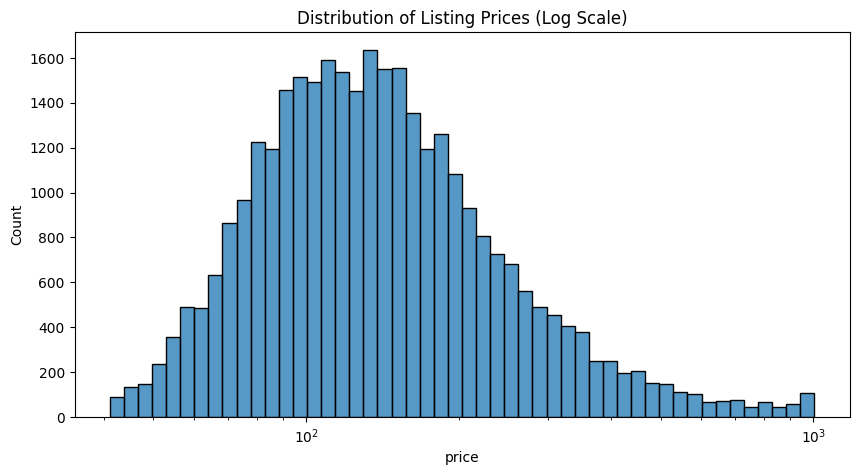

In [23]:
plt.figure(figsize=(10,5))

# Usamos log_scale=True para el eje X
sns.histplot(final_df["price"], bins=50, log_scale=True)

plt.title("Distribution of Listing Prices (Log Scale)")
plt.show()

## 6. Final Dataset Validation

Before exporting the final dataset, we verify:

- dataset dimensions
- variable types
- remaining missing values

In [24]:
print(final_df.shape)

(32902, 82)


In [25]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32902 entries, 0 to 33563
Data columns (total 82 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   price                                              32902 non-null  float64
 1   latitude                                           32902 non-null  float64
 2   longitude                                          32902 non-null  float64
 3   accommodates                                       32902 non-null  int64  
 4   bedrooms                                           32902 non-null  float64
 5   beds                                               32902 non-null  float64
 6   bathrooms                                          32902 non-null  float64
 7   host_is_superhost                                  32902 non-null  int64  
 8   host_response_rate                                 32902 non-null  float64
 9   host_accept

## 7. Export Final Dataset

The final integrated dataset is exported and will serve as the input for the machine learning models developed in Notebook 06.

In [26]:
final_df.to_csv(
    "../data/final_dataset.csv",
    index=False
)

print("final_dataset.csv saved")
print(final_df.shape)

final_dataset.csv saved
(32902, 82)


In [27]:
final_df.head()

,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,host_acceptance_rate,...,latest_review_day,days_since_latest_review,Seasonality_Index,month_sin,month_cos,season_Fall,season_Spring,season_Summer,season_Winter,season_no_reviews
0,57.0,41.871360,12.482150,1,1.0,1.0,1.5,0,0.0,0.0,...,8.0,4077.0,0.906591,5.000000e-01,-0.866025,False,True,False,False,False
1,110.0,41.895447,12.491181,2,1.0,1.0,1.0,1,100.0,95.0,...,7.0,29.0,0.899881,1.224647e-16,-1.000000,False,False,True,False,False
2,124.0,41.925820,12.469280,6,2.0,3.0,1.0,1,100.0,100.0,...,1.0,339.0,0.650089,-8.660254e-01,-0.500000,False,False,True,False,False
3,162.0,41.908230,12.452930,5,2.0,3.0,1.0,0,100.0,99.0,...,13.0,23.0,0.899881,1.224647e-16,-1.000000,False,False,True,False,False
4,150.0,41.908283,12.452617,5,2.0,3.0,1.0,0,100.0,99.0,...,-1.0,9999.0,0.000000,0.000000e+00,0.000000,False,False,False,False,True
